In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sushantkr878/train-data/train.csv


In [8]:
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

CUDA available: True
Tesla T4


In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

In [10]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/sushantkr878/train-data/train.csv


In [11]:
df = pd.read_csv('/kaggle/input/datasets/sushantkr878/train-data/train.csv')

In [12]:
df.head()

,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,...,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount
0,0,19.0,Female,10049.0,Married,1.0,Bachelor's,Self-Employed,22.598761,Urban,...,2.0,17.0,372.0,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0
1,1,39.0,Female,31678.0,Divorced,3.0,Master's,NaN,15.569731,Rural,...,1.0,12.0,694.0,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0
2,2,23.0,Male,25602.0,Divorced,3.0,High School,Self-Employed,47.177549,Suburban,...,1.0,14.0,NaN,3.0,2023-09-30 15:21:39.221386,Good,Yes,Weekly,House,567.0
3,3,21.0,Male,141855.0,Married,2.0,Bachelor's,NaN,10.938144,Rural,...,1.0,0.0,367.0,1.0,2024-06-12 15:21:39.226954,Poor,Yes,Daily,Apartment,765.0
4,4,21.0,Male,39651.0,Single,1.0,Bachelor's,Self-Employed,20.376094,Rural,...,0.0,8.0,598.0,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200000 entries, 0 to 1199999
Data columns (total 21 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1200000 non-null  int64  
 1   Age                   1181295 non-null  float64
 2   Gender                1200000 non-null  object 
 3   Annual Income         1155051 non-null  float64
 4   Marital Status        1181471 non-null  object 
 5   Number of Dependents  1090328 non-null  float64
 6   Education Level       1200000 non-null  object 
 7   Occupation            841925 non-null   object 
 8   Health Score          1125924 non-null  float64
 9   Location              1200000 non-null  object 
 10  Policy Type           1200000 non-null  object 
 11  Previous Claims       835971 non-null   float64
 12  Vehicle Age           1199994 non-null  float64
 13  Credit Score          1062118 non-null  float64
 14  Insurance Duration    1199999 non-

In [14]:
# Target Variable is ['Premium Amount']
# Its a Regression Probem
# Metric Used - Accuracy , Precision , Recall , F1 Score , ROC-AUC

In [15]:
df.shape

(1200000, 21)

In [16]:
df = df.drop('id', axis=1)

In [17]:
df.head()

,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount
0,19.0,Female,10049.0,Married,1.0,Bachelor's,Self-Employed,22.598761,Urban,Premium,2.0,17.0,372.0,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0
1,39.0,Female,31678.0,Divorced,3.0,Master's,NaN,15.569731,Rural,Comprehensive,1.0,12.0,694.0,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0
2,23.0,Male,25602.0,Divorced,3.0,High School,Self-Employed,47.177549,Suburban,Premium,1.0,14.0,NaN,3.0,2023-09-30 15:21:39.221386,Good,Yes,Weekly,House,567.0
3,21.0,Male,141855.0,Married,2.0,Bachelor's,NaN,10.938144,Rural,Basic,1.0,0.0,367.0,1.0,2024-06-12 15:21:39.226954,Poor,Yes,Daily,Apartment,765.0
4,21.0,Male,39651.0,Single,1.0,Bachelor's,Self-Employed,20.376094,Rural,Premium,0.0,8.0,598.0,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0


In [18]:
df.columns

Index(['Age', 'Gender', 'Annual Income', 'Marital Status',
       'Number of Dependents', 'Education Level', 'Occupation', 'Health Score',
       'Location', 'Policy Type', 'Previous Claims', 'Vehicle Age',
       'Credit Score', 'Insurance Duration', 'Policy Start Date',
       'Customer Feedback', 'Smoking Status', 'Exercise Frequency',
       'Property Type', 'Premium Amount'],
      dtype='object')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200000 entries, 0 to 1199999
Data columns (total 20 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   Age                   1181295 non-null  float64
 1   Gender                1200000 non-null  object 
 2   Annual Income         1155051 non-null  float64
 3   Marital Status        1181471 non-null  object 
 4   Number of Dependents  1090328 non-null  float64
 5   Education Level       1200000 non-null  object 
 6   Occupation            841925 non-null   object 
 7   Health Score          1125924 non-null  float64
 8   Location              1200000 non-null  object 
 9   Policy Type           1200000 non-null  object 
 10  Previous Claims       835971 non-null   float64
 11  Vehicle Age           1199994 non-null  float64
 12  Credit Score          1062118 non-null  float64
 13  Insurance Duration    1199999 non-null  float64
 14  Policy Start Date     1200000 non-

In [20]:
df.isnull().sum()

Age                      18705
Gender                       0
Annual Income            44949
Marital Status           18529
Number of Dependents    109672
Education Level              0
Occupation              358075
Health Score             74076
Location                     0
Policy Type                  0
Previous Claims         364029
Vehicle Age                  6
Credit Score            137882
Insurance Duration           1
Policy Start Date            0
Customer Feedback        77824
Smoking Status               0
Exercise Frequency           0
Property Type                0
Premium Amount               0
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.describe()

,Age,Annual Income,Number of Dependents,Health Score,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Premium Amount
count,1.181295e+06,1.155051e+06,1.090328e+06,1.125924e+06,835971.000000,1.199994e+06,1.062118e+06,1.199999e+06,1.200000e+06
mean,4.114556e+01,3.274522e+04,2.009934e+00,2.561391e+01,1.002689,9.569889e+00,5.929244e+02,5.018219e+00,1.102545e+03
std,1.353995e+01,3.217951e+04,1.417338e+00,1.220346e+01,0.982840,5.776189e+00,1.499819e+02,2.594331e+00,8.649989e+02
min,1.800000e+01,1.000000e+00,0.000000e+00,2.012237e+00,0.000000,0.000000e+00,3.000000e+02,1.000000e+00,2.000000e+01
25%,3.000000e+01,8.001000e+03,1.000000e+00,1.591896e+01,0.000000,5.000000e+00,4.680000e+02,3.000000e+00,5.140000e+02
50%,4.100000e+01,2.391100e+04,2.000000e+00,2.457865e+01,1.000000,1.000000e+01,5.950000e+02,5.000000e+00,8.720000e+02
75%,5.300000e+01,4.463400e+04,3.000000e+00,3.452721e+01,2.000000,1.500000e+01,7.210000e+02,7.000000e+00,1.509000e+03
max,6.400000e+01,1.499970e+05,4.000000e+00,5.897591e+01,9.000000,1.900000e+01,8.490000e+02,9.000000e+00,4.999000e+03


In [23]:
df["Premium Amount"].value_counts(dropna = False)

Premium Amount
25.0      4268
24.0      3901
20.0      3849
23.0      3524
28.0      3418
          ... 
4107.0       1
4996.0       1
4937.0       1
4507.0       1
4925.0       1
Name: count, Length: 4794, dtype: int64

In [24]:
df["Premium Amount"].describe()

count    1.200000e+06
mean     1.102545e+03
std      8.649989e+02
min      2.000000e+01
25%      5.140000e+02
50%      8.720000e+02
75%      1.509000e+03
max      4.999000e+03
Name: Premium Amount, dtype: float64

# Short summary 

Dataset Shape: 1200000 × 21

Target: - ["Premium Amount"] (binary classification)


Data Quality:
- 9 columns have missing values
- 0 duplicate rows found


Data Types:
- 10 numerical
- 10 categorical
- 0 date column

Premium Amount:
- No obvious data quality issues found.
- Distribution appears reasonable.
- Further outlier analysis needed during EDA.

# EDA
- Understand the data deeply and discover patterns, problems, and insights that will influence preprocessing and model building.

In [25]:
df["Premium Amount"].value_counts()

Premium Amount
25.0      4268
24.0      3901
20.0      3849
23.0      3524
28.0      3418
          ... 
4107.0       1
4996.0       1
4937.0       1
4507.0       1
4925.0       1
Name: count, Length: 4794, dtype: int64

<Axes: >

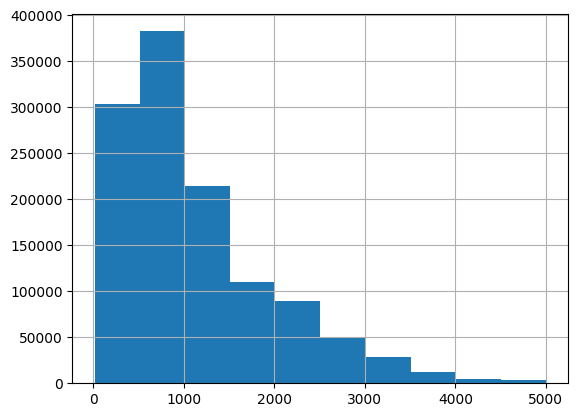

In [26]:
df["Premium Amount"].hist()

In [27]:
# THis is not a normal distribution . MOst data points clustered on the left and a tail extending to the right . 
# It is right skewed (Positive skewed).
# THere are extreme values / outliers typically isolated bars far to the right or left of the main data cluster . 

In [28]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns

cat_cols = df.select_dtypes(include=["object"]).columns

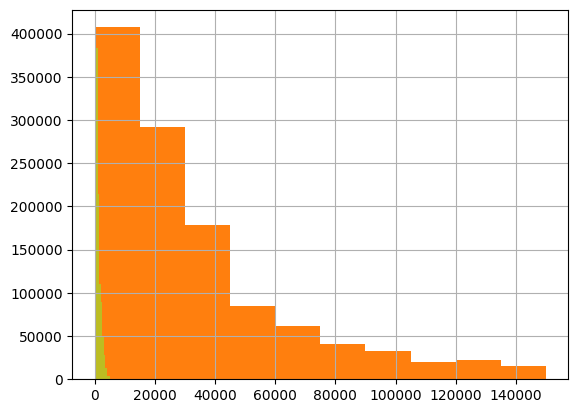

In [29]:
for col in num_cols:
    df[col].hist()

In [30]:
# This is not a normal distribution . 
# And this is Right-skewed distribution .  

In [31]:
df[num_cols].describe()

,Age,Annual Income,Number of Dependents,Health Score,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Premium Amount
count,1.181295e+06,1.155051e+06,1.090328e+06,1.125924e+06,835971.000000,1.199994e+06,1.062118e+06,1.199999e+06,1.200000e+06
mean,4.114556e+01,3.274522e+04,2.009934e+00,2.561391e+01,1.002689,9.569889e+00,5.929244e+02,5.018219e+00,1.102545e+03
std,1.353995e+01,3.217951e+04,1.417338e+00,1.220346e+01,0.982840,5.776189e+00,1.499819e+02,2.594331e+00,8.649989e+02
min,1.800000e+01,1.000000e+00,0.000000e+00,2.012237e+00,0.000000,0.000000e+00,3.000000e+02,1.000000e+00,2.000000e+01
25%,3.000000e+01,8.001000e+03,1.000000e+00,1.591896e+01,0.000000,5.000000e+00,4.680000e+02,3.000000e+00,5.140000e+02
50%,4.100000e+01,2.391100e+04,2.000000e+00,2.457865e+01,1.000000,1.000000e+01,5.950000e+02,5.000000e+00,8.720000e+02
75%,5.300000e+01,4.463400e+04,3.000000e+00,3.452721e+01,2.000000,1.500000e+01,7.210000e+02,7.000000e+00,1.509000e+03
max,6.400000e+01,1.499970e+05,4.000000e+00,5.897591e+01,9.000000,1.900000e+01,8.490000e+02,9.000000e+00,4.999000e+03


In [32]:
# Annual Income:
# Min = 1
# Max = 149,997

# This means : 
#         - Distribution may be skewed
#         - Outlier analysis may be needed
#         - Linear models may benefit from transformations

# Final :

#      - No obvious impossible maximum values
#      - Annual Income minimum (1) should be investigated
#      - Annual Income has a wide range
#      - Other numerical features appear reasonable

In [33]:
for col in cat_cols:
    print(df[col].value_counts())

Gender
Male      602571
Female    597429
Name: count, dtype: int64
Marital Status
Single      395391
Married     394316
Divorced    391764
Name: count, dtype: int64
Education Level
Master's       303818
PhD            303507
Bachelor's     303234
High School    289441
Name: count, dtype: int64
Occupation
Employed         282750
Self-Employed    282645
Unemployed       276530
Name: count, dtype: int64
Location
Suburban    401542
Rural       400947
Urban       397511
Name: count, dtype: int64
Policy Type
Premium          401846
Comprehensive    399600
Basic            398554
Name: count, dtype: int64
Policy Start Date
2020-02-08 15:21:39.134960    142
2022-02-02 15:21:39.134960    137
2023-08-13 15:21:39.155231    137
2022-08-30 15:21:39.134960    134
2024-02-19 15:21:39.134960    118
                             ... 
2022-09-24 15:21:39.199447      1
2020-09-17 15:21:39.258696      1
2021-08-20 15:21:39.286113      1
2022-12-30 15:21:39.257696      1
2024-07-22 15:21:39.217387      1
Na

In [34]:
# Policy Start Date
#        Length: 167381 unique values =  High-cardinality column(contains an exceptionally 
#        large number of distinct values relative to the total number of rows.)


# The others:

# Gender → 2
# Marital Status → 3
# Education Level → 4
# Occupation → 3
# Location → 3
# Policy Type → 3
# Customer Feedback → 3
# Smoking Status → 2
# Exercise Frequency → 4
# Property Type → 3

# These are low cardinality.




#     Categorical Features:

# One-Hot Encoding:
# - Gender
# - Marital Status
# - Occupation
# - Smoking Status
# - Location
# - Policy Type
# - Property Type

# Ordinal Encoding:
# - Education Level
# - Customer Feedback
# - Exercise Frequency

# Date Feature:
# - Policy Start Date
#   -> Convert to datetime
#   -> Extract Year, Month, Day, Weekday

# High Cardinality:
# - Policy Start Date (~167k unique values)

# Rare Categories:
# - None detected

# Typing Errors:
# - None detected




#  No rare categories found.
#  No typing mistakes.

In [35]:
df.isnull().sum()

Age                      18705
Gender                       0
Annual Income            44949
Marital Status           18529
Number of Dependents    109672
Education Level              0
Occupation              358075
Health Score             74076
Location                     0
Policy Type                  0
Previous Claims         364029
Vehicle Age                  6
Credit Score            137882
Insurance Duration           1
Policy Start Date            0
Customer Feedback        77824
Smoking Status               0
Exercise Frequency           0
Property Type                0
Premium Amount               0
dtype: int64

In [36]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

Previous Claims         30.335750
Occupation              29.839583
Credit Score            11.490167
Number of Dependents     9.139333
Customer Feedback        6.485333
Health Score             6.173000
Annual Income            3.745750
Age                      1.558750
Marital Status           1.544083
Vehicle Age              0.000500
Insurance Duration       0.000083
Gender                   0.000000
Location                 0.000000
Policy Type              0.000000
Education Level          0.000000
Policy Start Date        0.000000
Smoking Status           0.000000
Exercise Frequency       0.000000
Property Type            0.000000
Premium Amount           0.000000
dtype: float64

In [37]:
# Now understand:

# Missing Values Analysis

# Very High Missing:
# - Previous Claims (~30%)
# - Occupation (~30%)

# Moderate Missing:
# - Credit Score (~11%)
# - Number of Dependents (~9%)
# - Customer Feedback (~6%)
# - Health Score (~6%)

# Low Missing:
# - Annual Income (~4%)
# - Age (~1.5%)
# - Marital Status (~1.5%)

# Negligible Missing:
# - Vehicle Age (6 rows)
# - Insurance Duration (1 row)




# Categorical columns with missing values:
#                    - Marital Status
#                    - Occupation
#                    - Customer Feedback



# Numerical columns with missing values:  Median (usually preferred)
#                   Age
#                   Annual Income
#                   Number of Dependents
#                   Health Score
#                   Previous Claims
#                   Credit Score
#                   Vehicle Age
#                   Insurance Duration






# ✓ Regression problem
# ✓ Target: Premium Amount

# ✓ No obvious data quality issues in numerical columns
# ✓ Annual Income min=1 should be investigated

# ✓ No rare categories
# ✓ No obvious typing errors

# ✓ High-cardinality:
#   - Policy Start Date

# ✓ Encoding Plan:
#   - OneHot: Gender, Marital Status, Occupation, Smoking Status,
#             Location, Policy Type, Property Type
#   - Ordinal: Education Level, Customer Feedback,
#              Exercise Frequency

# ✓ Missing values present in 11 columns
# ✓ Previous Claims and Occupation have ~30% missing values

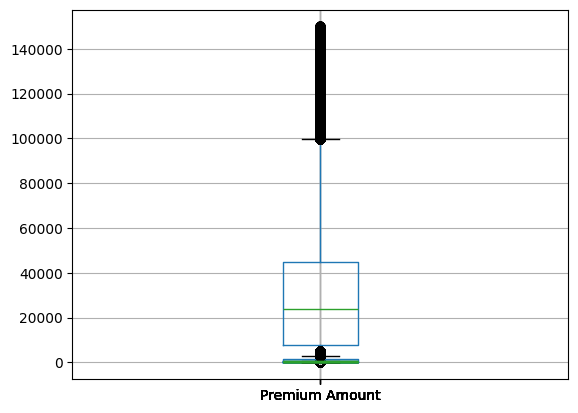

In [38]:
for col in num_cols:
    df.boxplot(column=col)

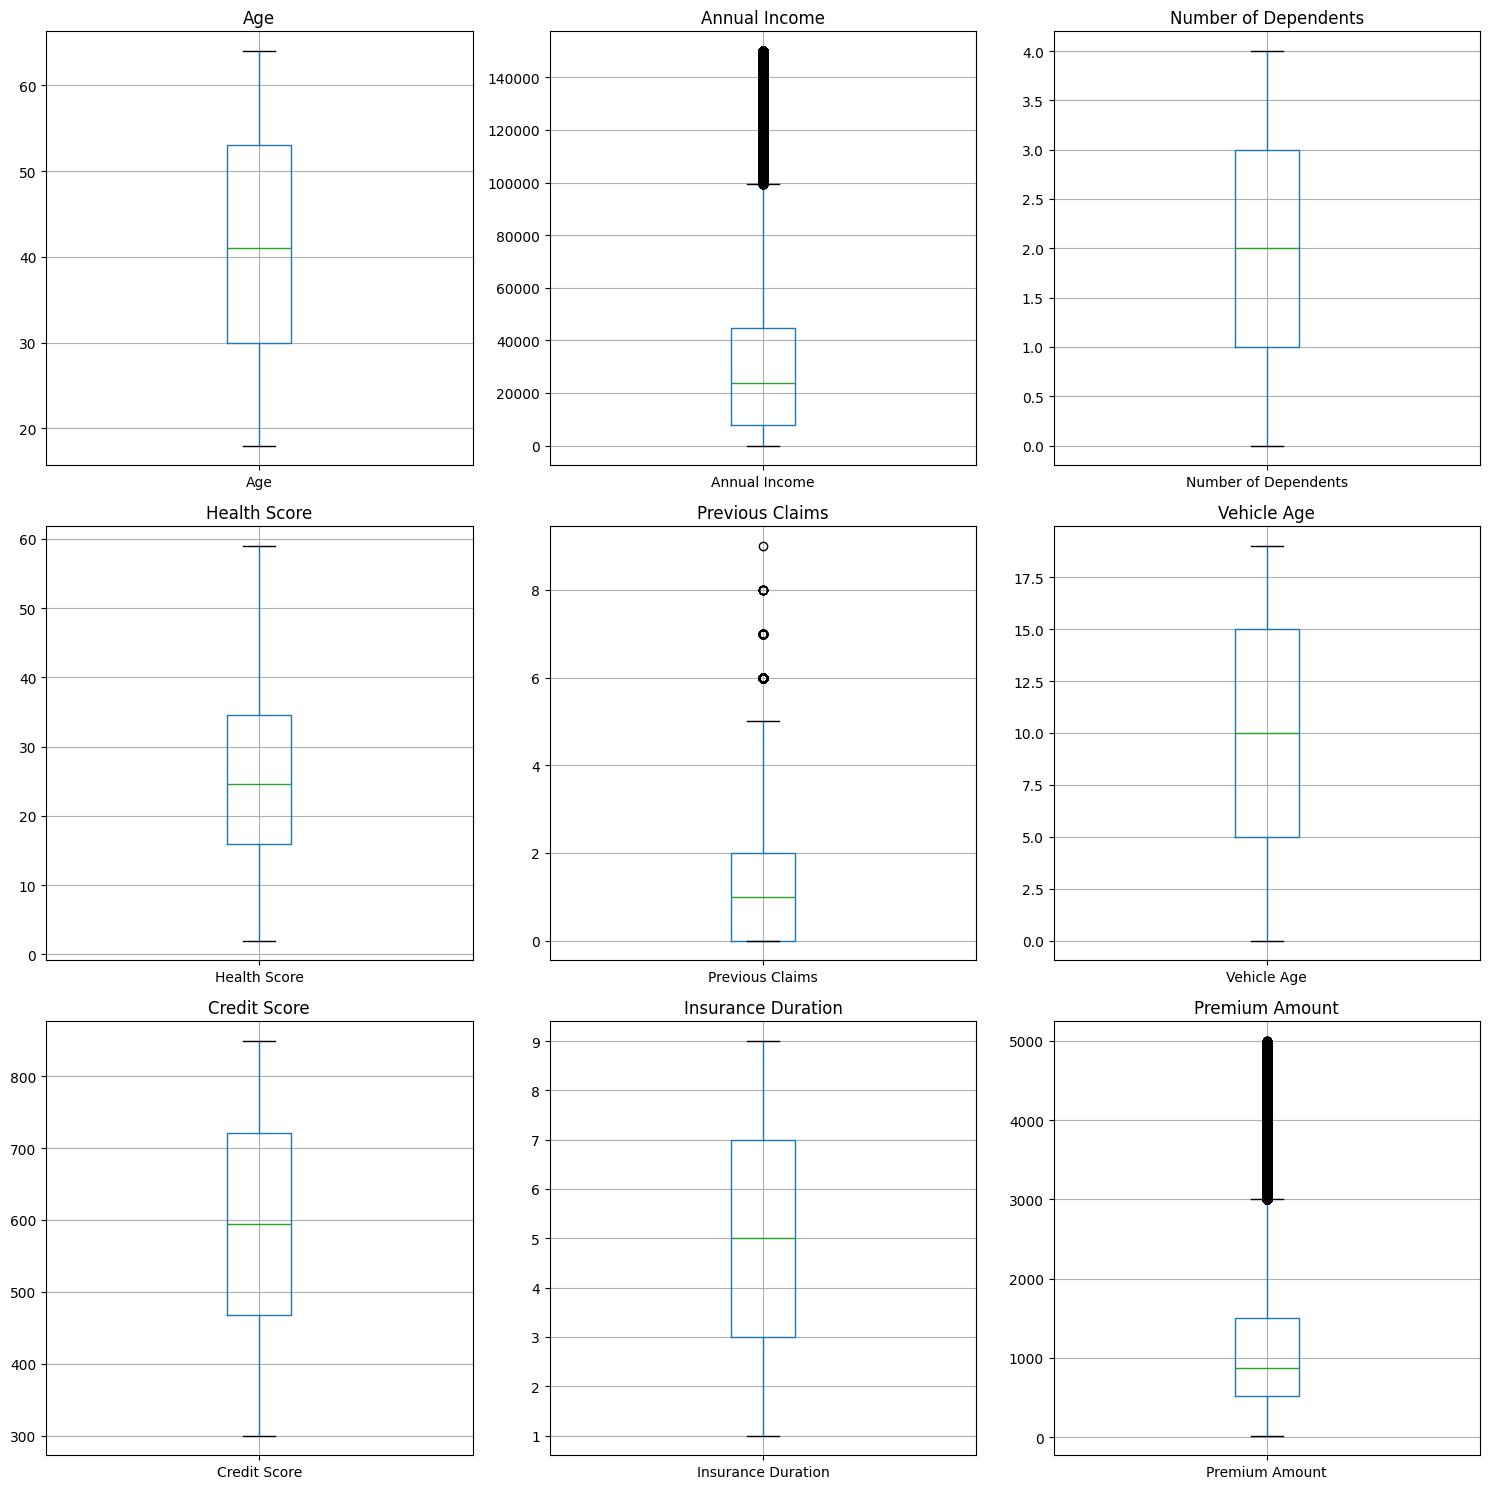

In [39]:
import math

n_cols = 3  # number of plots per row
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [40]:
# No obvious data-entry errors

# ✓ Outliers detected in Premium Amount.
# ✓ Some observations lie far from the majority of the data.
# ✓ Distribution appears right-skewed.
# ✓ Outliers identified during EDA.
# ✓ No outliers removed at this stage.
# ✓ Further investigation required after train-test split.

In [41]:
df[num_cols].corr()

,Age,Annual Income,Number of Dependents,Health Score,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Premium Amount
Age,1.000000,-0.000009,0.001475,0.000881,0.001869,-0.002455,0.002842,-0.000064,-0.002430
Annual Income,-0.000009,1.000000,0.002135,0.025530,0.043065,-0.000500,-0.201423,0.000379,-0.012390
Number of Dependents,0.001475,0.002135,1.000000,0.005152,-0.004123,0.001232,-0.001714,-0.000265,-0.000976
Health Score,0.000881,0.025530,0.005152,1.000000,0.001989,0.000316,0.012016,0.002487,0.014704
Previous Claims,0.001869,0.043065,-0.004123,0.001989,1.000000,-0.001172,0.036816,0.003001,0.046874
Vehicle Age,-0.002455,-0.000500,0.001232,0.000316,-0.001172,1.000000,0.000508,0.003132,0.000391
Credit Score,0.002842,-0.201423,-0.001714,0.012016,0.036816,0.000508,1.000000,0.000493,-0.026014
Insurance Duration,-0.000064,0.000379,-0.000265,0.002487,0.003001,0.003132,0.000493,1.000000,-0.000028
Premium Amount,-0.002430,-0.012390,-0.000976,0.014704,0.046874,0.000391,-0.026014,-0.000028,1.000000


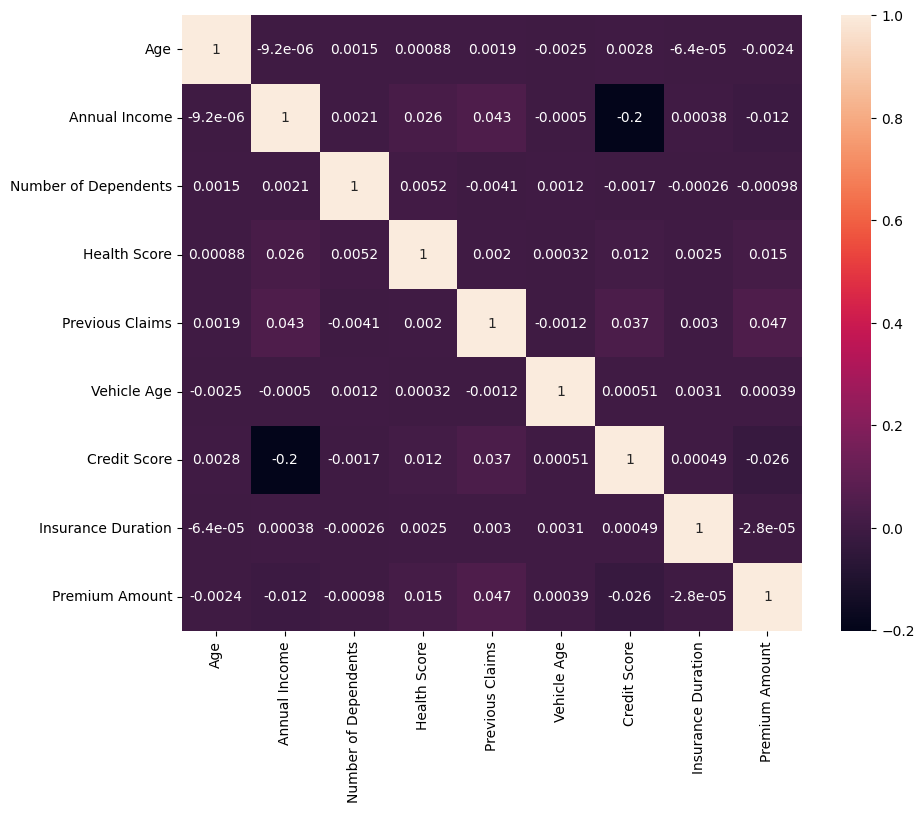

In [42]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr() , annot = True)
plt.savefig('Heatmap.png')

In [43]:
# # Highly correlated features
#       Usually we look for:  |correlation| > 0.7 or 0.8 

#       But in this Heatmap: Annual Income ↔ Credit Score = -0.20
#       - This is the largest correlation.
#           Since: |-0.20| < 0.7

#        No highly correlated features found.



# # Potential multicollinearity

# Multicollinearity occurs when features are highly correlated with each other.

# Examples:

# Salary ↔ Income = 0.95
# Height(cm) ↔ Height(m) = 1.00

# In this heatmap:

# Most correlations are between -0.20 and +0.05

#  -No significant multicollinearity detected.

In [44]:
# Correlation Analysis

# ✓ No highly correlated numerical features found.
# ✓ Maximum correlation observed:
#   Annual Income ↔ Credit Score = -0.20

# ✓ No evidence of multicollinearity.
# ✓ Numerical features appear largely independent.
# ✓ Feature removal based on correlation is not required.

#  EDA Notes-

1. Problem Type

* Regression Problem
* Target Variable: Premium Amount

2. Dataset Overview

* Rows: 1,200,000
* Columns: 21
* Numerical Features: 10 (including target)
* Categorical Features: 11

3. Data Quality Checks

* No duplicate rows detected.
* No obvious typing inconsistencies found in categorical features.
* No obvious impossible values found in numerical features.
* Annual Income minimum value = 1, should be investigated further.

4. Missing Values
   Columns requiring imputation:

* Age
* Annual Income
* Marital Status
* Number of Dependents
* Occupation
* Health Score
* Previous Claims
* Credit Score
* Vehicle Age
* Insurance Duration
* Customer Feedback

High Missing Percentage:

* Previous Claims (~30%)
* Occupation (~30%)

Moderate Missing Percentage:

* Credit Score (~11%)
* Number of Dependents (~9%)
* Customer Feedback (~6%)
* Health Score (~6%)

Low Missing Percentage:

* Annual Income (~4%)
* Age (~1.5%)
* Marital Status (~1.5%)

5. Categorical Feature Analysis
   Rare Categories:

* None detected.

Typing Errors:

* None detected.

High Cardinality:

* Policy Start Date (~167k unique values)

6. Planned Encoding Strategy
   One-Hot Encoding:

* Gender
* Marital Status
* Occupation
* Smoking Status
* Location
* Policy Type
* Property Type

Ordinal Encoding:

* Education Level
  High School < Bachelor's < Master's < PhD

* Customer Feedback
  Poor < Average < Good

* Exercise Frequency
  Rarely < Monthly < Weekly < Daily

7. Date Feature Handling
   Policy Start Date:

* Convert to datetime
* Extract:

  * Year
  * Month
  * Day
  * Weekday

8. Numerical Feature Analysis

* No obvious unrealistic maximum values detected.
* Annual Income has a wide range.
* Numerical distributions require further preprocessing analysis after train-test split.

9. Outlier Analysis

* Outliers detected in Premium Amount.
* Potential outliers may exist in other numerical features.
* Outliers identified but not removed during EDA.
* Further investigation required after train-test split.

10. Correlation Analysis

* No highly correlated numerical features detected.
* Highest observed correlation:
  Annual Income ↔ Credit Score = -0.20
* No significant multicollinearity detected.
* Feature removal based on correlation is not required.

11. Preliminary Feature Engineering Ideas

* Extract features from Policy Start Date.
* Consider handling skewed numerical features if necessary.
* Consider creating domain-based features after train-test split.

12. Leakage Prevention Plan

* Perform Train-Test Split before preprocessing.
* Fit all preprocessing objects only on training data.
* Apply fitted transformations to test data using transform() only.


# Train-Test Split

In [45]:
X = df.drop("Premium Amount", axis=1)

y = df["Premium Amount"]

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [47]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)



(960000, 19)
(240000, 19)
(960000,)
(240000,)


In [48]:
# Train-Test Split

# - Features and target separated.
# - Test size = 20%.
# - Random state = 42 for reproducibility.
# - Training set will be used for:
#   - Imputation
#   - Encoding
#   - Feature engineering
#   - Scaling
#   - Model training

# - Test set reserved for final evaluation only.
# - No preprocessing object will be fitted on test data.







# Only on X_train i will perform these things:

#    Missing value imputation, Encoding , Feature engineering ,
#    Scaling,  Feature selection, PCA, Model training . 

# Detailed EDA on X_train

In [49]:
(X_train.isnull().sum()/len(X_train)*100).sort_values(ascending=False)

Previous Claims         30.328646
Occupation              29.856354
Credit Score            11.486875
Number of Dependents     9.152500
Customer Feedback        6.489062
Health Score             6.180104
Annual Income            3.741042
Age                      1.567500
Marital Status           1.548229
Vehicle Age              0.000417
Insurance Duration       0.000104
Gender                   0.000000
Policy Type              0.000000
Education Level          0.000000
Location                 0.000000
Policy Start Date        0.000000
Smoking Status           0.000000
Exercise Frequency       0.000000
Property Type            0.000000
dtype: float64

In [50]:
# 1. Previous Claims ,Occupation , Credit Score , Number of Dependents , Customer Feedback
#    Health Score , Annual Income , Age , Marital Status . These columns have missing values and need imputation .  
# 2. Previous Claims ,Occupation , Credit Score columns have high missing percentages?
# 3. No column would be dropped due to excessive missing values .

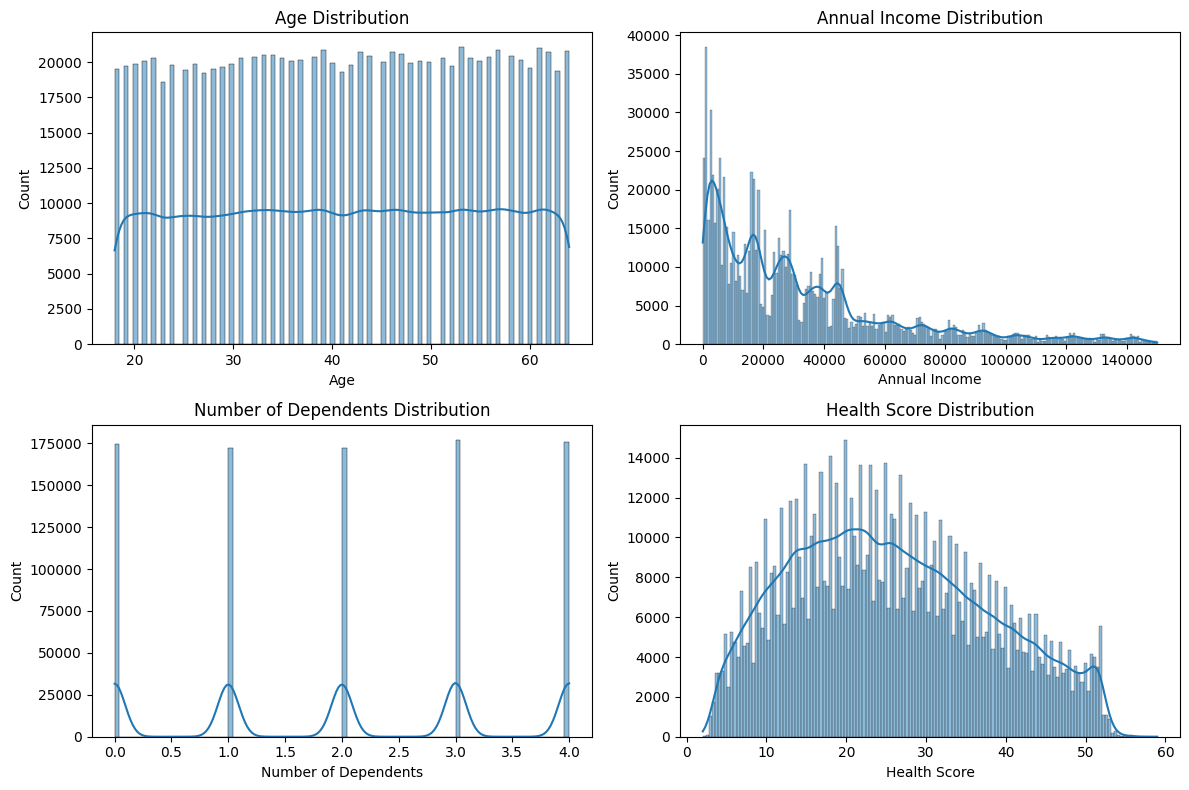

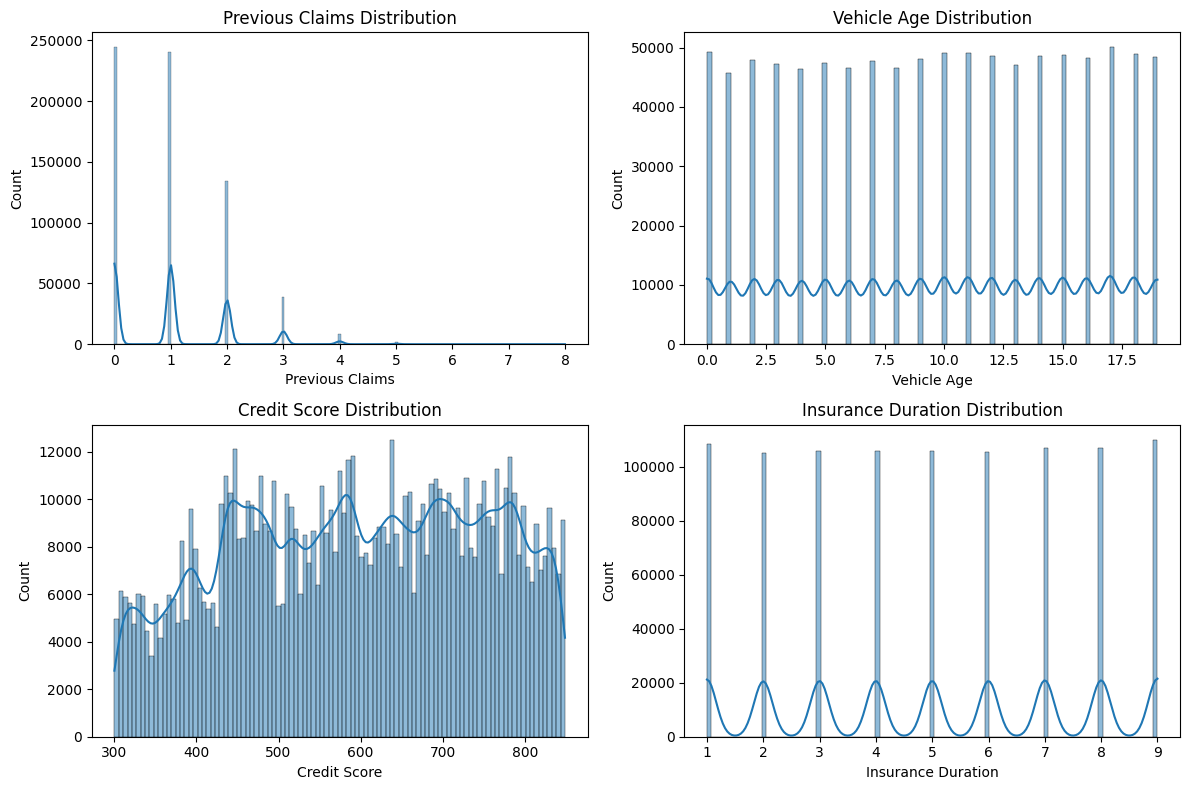

In [51]:
num_cols_train = X_train.select_dtypes(include=['int64', 'float64']).columns

# Plot 4 distributions at a time
for i in range(0, len(num_cols_train), 4):

    cols = num_cols_train[i:i+4]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for ax, col in zip(axes, cols):
        sns.histplot(X_train[col], kde=True, ax=ax)
        ax.set_title(f'{col} Distribution')

    # Hide unused subplots if fewer than 4 columns remain
    for ax in axes[len(cols):]:
        ax.set_visible(False)

    
    plt.savefig('Distribution.png')
    plt.tight_layout()
    plt.show()

In [52]:
# Previous Claims:
# 1. Normal? → No
# 2. Right-skewed? → Yes (strongly)
# 3. Left-skewed? → No
# 4. Multiple peaks? → No
# 5. Need transformation? → No immediate need (tree models)

# Note:

# - Most customers have 0–2 claims.
# - Higher claim counts are rare.
# - Strong right skew.





# Vehicle Age
# 1. Normal? → No
# 2. Right-skewed? → No
# 3. Left-skewed? → No
# 4. Multiple peaks? → No
# 5. Need transformation? → No

# Note:

# - Nearly uniform distribution.
# - Vehicle ages are evenly spread.






# Credit Score
# 1. Normal? → Approximately No
# 2. Right-skewed? → Slightly
# 3. Left-skewed? → Slightly
# 4. Multiple peaks? → Yes
# 5. Need transformation? → No

# Note:

# - Scores spread across entire range.
# - No severe skewness. 




# Insurance Duration
# 1. Normal? → No
# 2. Right-skewed? → No
# 3. Left-skewed? → No
# 4. Multiple peaks? → Yes
# 5. Need transformation? → No

# Note:

# - Discrete feature (1–9 years).
# - Almost equally distributed.

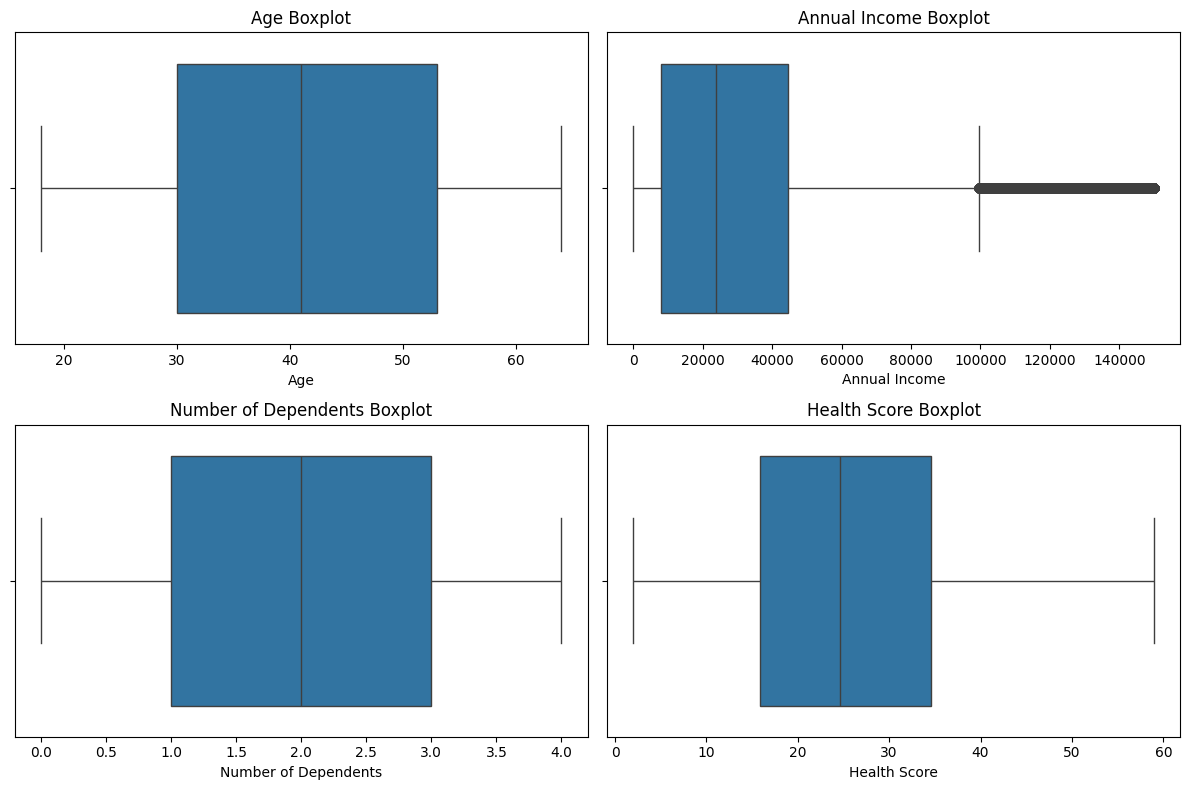

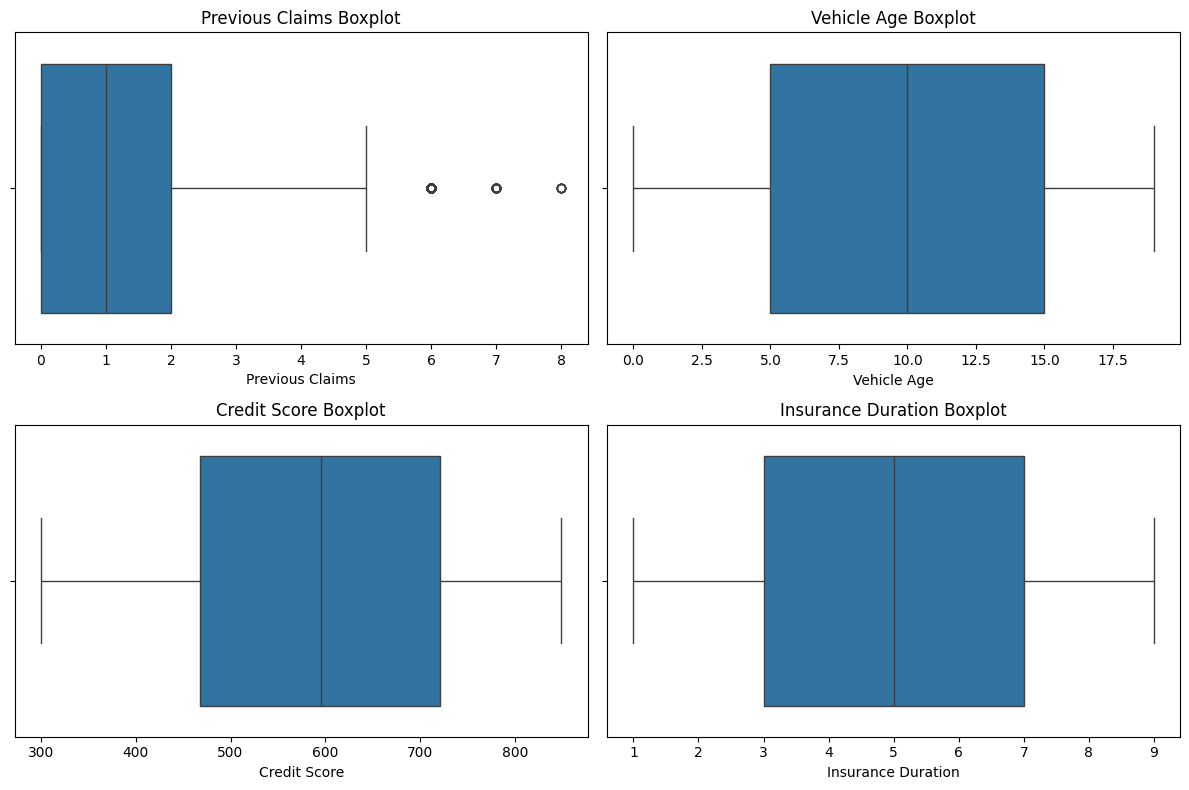

In [53]:
for i in range(0, len(num_cols_train), 4):

    cols = num_cols_train[i:i+4]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for ax, col in zip(axes, cols):
        sns.boxplot(x=X_train[col], ax=ax)
        ax.set_title(f'{col} Boxplot')

    # Hide unused subplots
    for ax in axes[len(cols):]:
        ax.set_visible(False)
        
    plt.savefig('Boxplot.png')
    plt.tight_layout()
    plt.show()

In [54]:
# Previous Claims
# 1. Outliers present? → Yes
# 2. How many? → Few
# 3. Extreme? → Mild
# 4. Investigate later? → Yes
# 5. Spread? → Narrow

# Note:

# - Outliers at 6,7,8 claims.
# - Majority of customers have ≤2 claims.



# Vehicle Age
# 1. Outliers present? → No
# 2. How many? → None
# 3. Extreme? → No
# 4. Investigate later? → No
# 5. Spread? → Wide



# Credit Score
# 1. Outliers present? → No
# 2. How many? → None
# 3. Extreme? → No
# 4. Investigate later? → No
# 5. Spread? → Moderate



# Insurance Duration
# 1. Outliers present? → No
# 2. How many? → None
# 3. Extreme? → No
# 4. Investigate later? → No
# 5. Spread? → Moderate

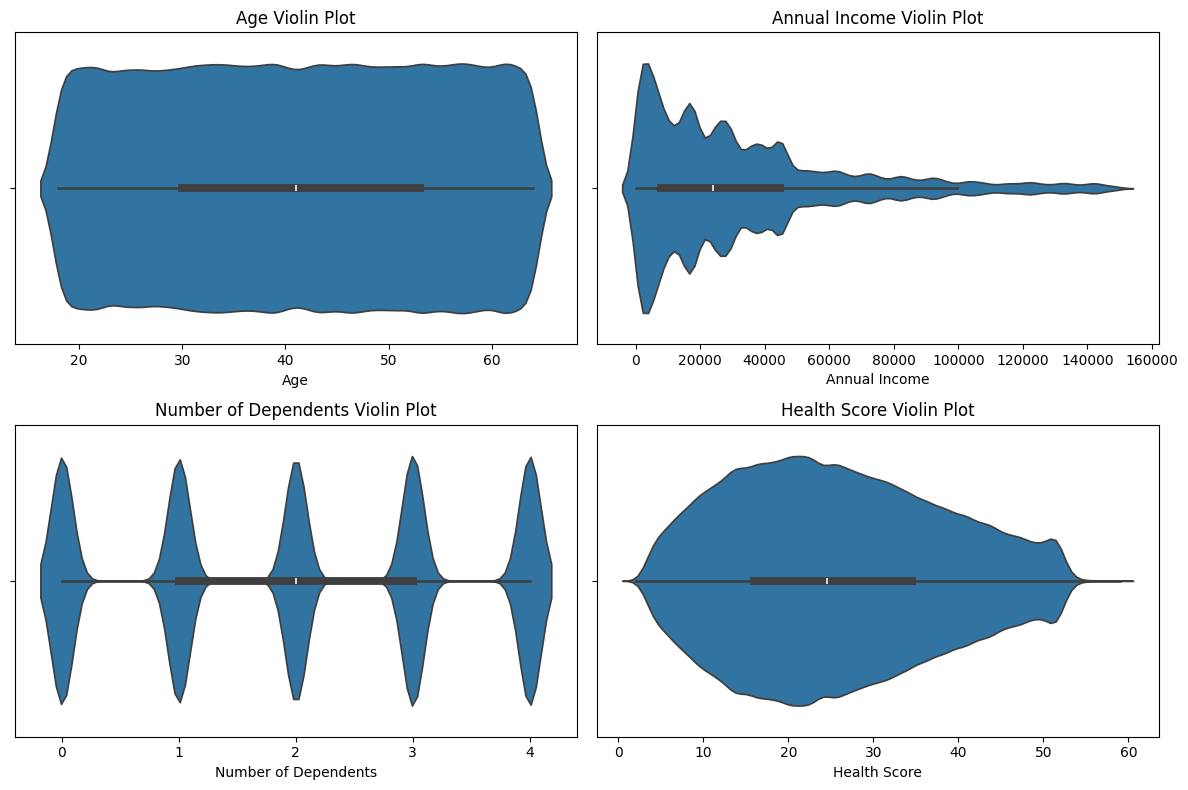

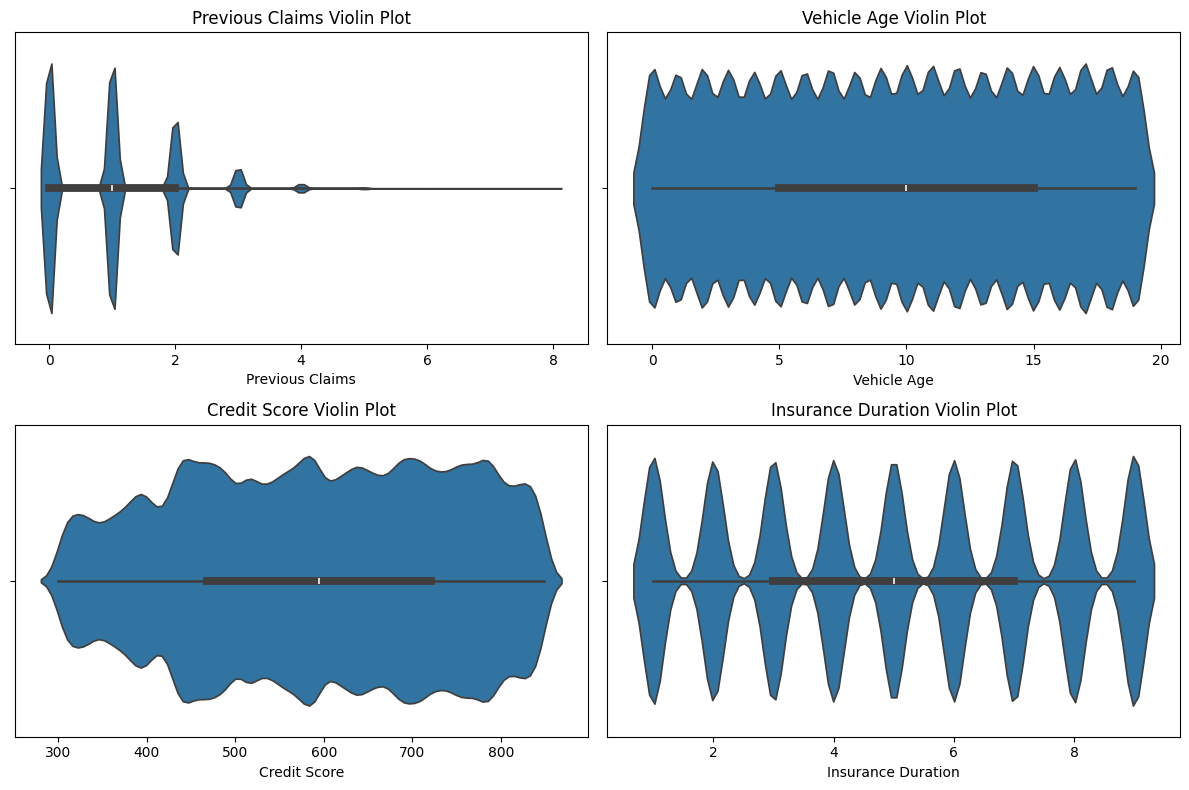

In [55]:
for i in range(0, len(num_cols_train), 4):

    cols = num_cols_train[i:i+4]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for ax, col in zip(axes, cols):
        sns.violinplot(x=X_train[col], ax=ax)
        ax.set_title(f'{col} Violin Plot')

    # Hide unused subplots
    for ax in axes[len(cols):]:
        ax.set_visible(False)

    plt.savefig('ViolinPlot.png')
    plt.tight_layout()
    plt.show()

In [56]:
# Previous Claims
# 1. Data concentrated? → Around 0–2
# 2. Symmetric? → No
# 3. Multiple clusters? → No
# 4. Skewed? → Yes



# Vehicle Age
# 1. Data concentrated? → Entire range
# 2. Symmetric? → Yes
# 3. Multiple clusters? → No
# 4. Skewed? → No



# Credit Score
# 1. Data concentrated? → 450–800
# 2. Symmetric? → Roughly
# 3. Multiple clusters? → Slightly
# 4. Skewed? → Mild



# Insurance Duration
# 1. Data concentrated? → All durations
# 2. Symmetric? → Yes
# 3. Multiple clusters? → Due to discrete values
# 4. Skewed? → No

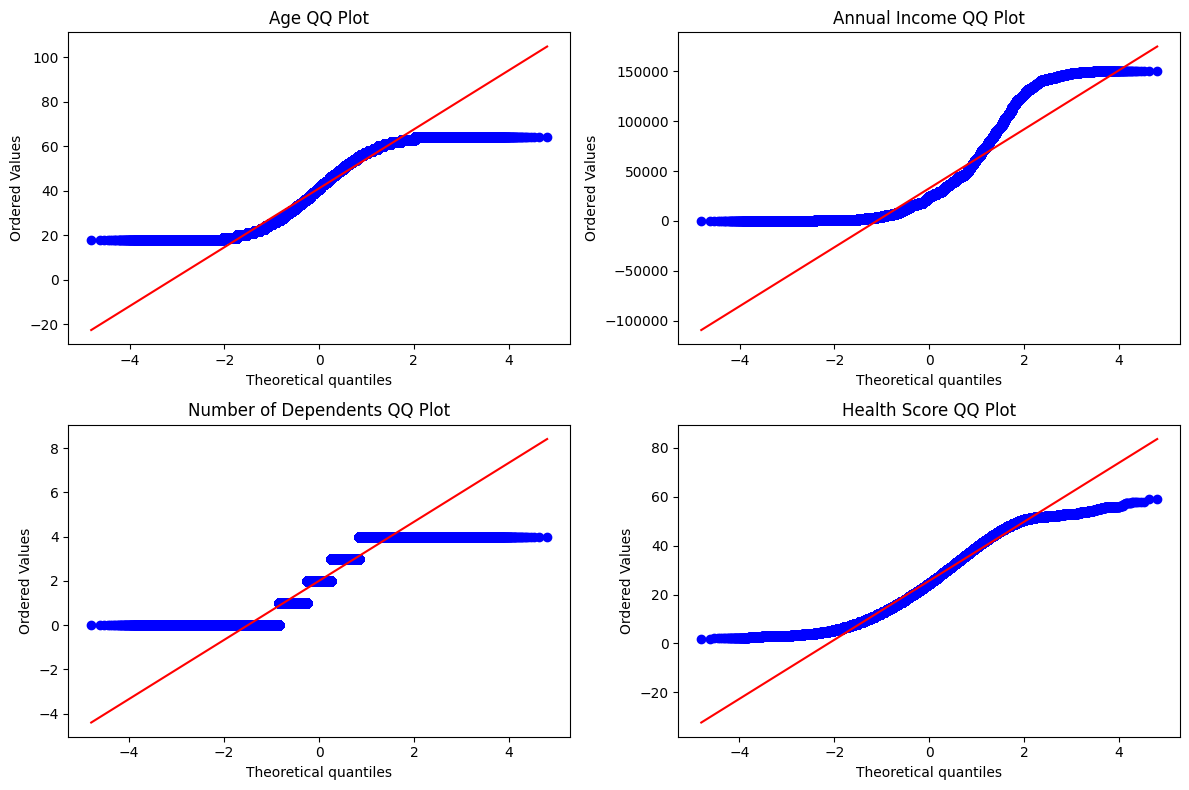

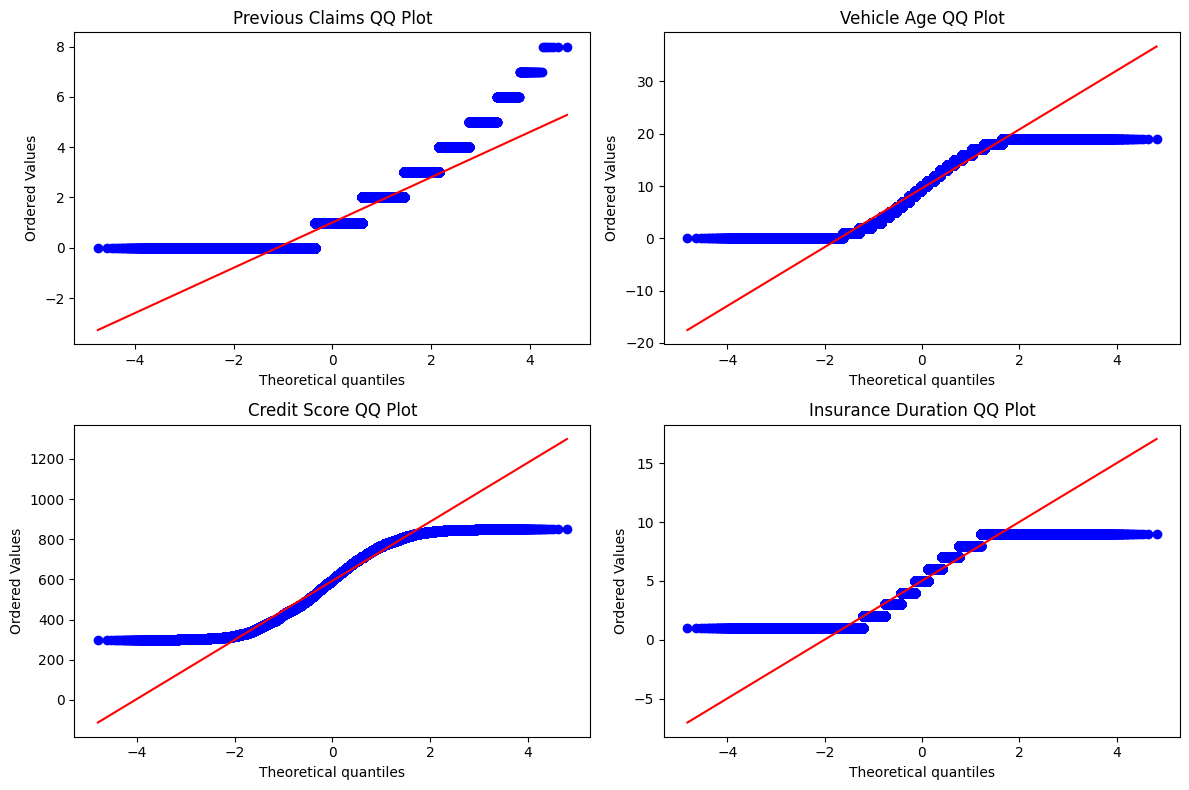

In [57]:
for i in range(0, len(num_cols_train), 4):

    cols = num_cols_train[i:i+4]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for ax, col in zip(axes, cols):
        stats.probplot(
            X_train[col].dropna(),
            dist="norm",
            plot=ax
        )
        ax.set_title(f'{col} QQ Plot')

    # Hide unused subplots
    for ax in axes[len(cols):]:
        ax.set_visible(False)

    plt.savefig('StraightLine.png')
    plt.tight_layout()
    plt.show()

In [58]:
# A QQ Plot compares: Your Data vs Perfect Normal Distribution 

# Previous Claims QQ Plot
# 1. Straight line? → No
# 2. Approximately normal? → No
# 3. Tail deviations? → Strong
# 4. Transformation helpful? → Maybe



# Vehicle Age QQ Plot
# 1. Straight line? → No
# 2. Approximately normal? → No
# 3. Tail deviations? → Yes
# 4. Transformation helpful? → No



# Credit Score QQ Plot
# 1. Straight line? → Partially
# 2. Approximately normal? → Closest among these features
# 3. Tail deviations? → Moderate
# 4. Transformation helpful? → Not needed



# Insurance Duration QQ Plot
# 1. Straight line? → No
# 2. Approximately normal? → No
# 3. Tail deviations? → Strong
# 4. Transformation helpful? → No

# Final Notes for These 4 Features 
Previous Claims
- Right-skewed
- Contains outliers
- Not normally distributed

Vehicle Age
- Uniform distribution
- No outliers
- Not normally distributed

Credit Score
- Well spread
- No outliers
- Closest to normal among these features

Insurance Duration
- Discrete feature
- No outliers
- Not normally distributed


For tree-based models (Random Forest, XGBoost, LightGBM, CatBoost), normality is usually not important. 
The QQ plot becomes much more important for using Linear Regression, Ridge, Lasso, or models that assume linear relationships.

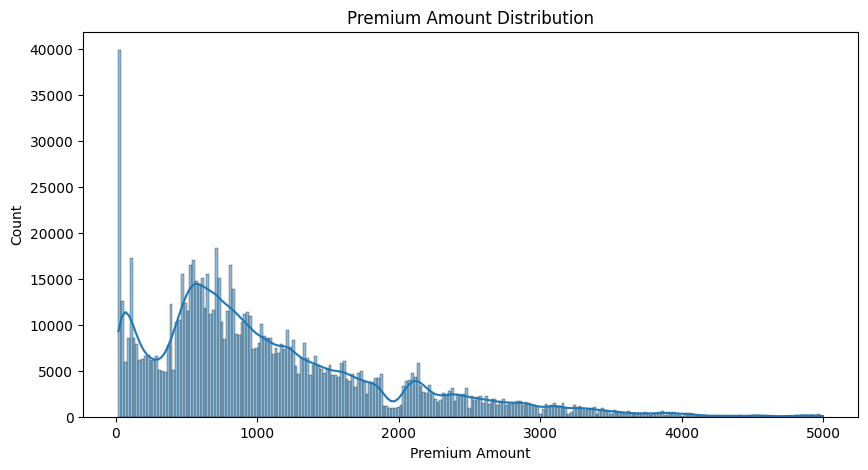

In [59]:
# Target Variable Analysis 
plt.figure(figsize=(10,5))

sns.histplot(y_train, kde=True)

plt.title("Premium Amount Distribution")
plt.show()

In [60]:
# 1. It is not normally distributed?
# 2. Is it right-skewed . 
# 3. Yes , extreme premiums are present , values are reachingup to and beyond 50000 
#    while majority of the data is clustered between 0 and 2000 . 
# 4. Yes , target transformation is needed . use- Log transformation , Square Root or Box-Cox to normalize distribution . 

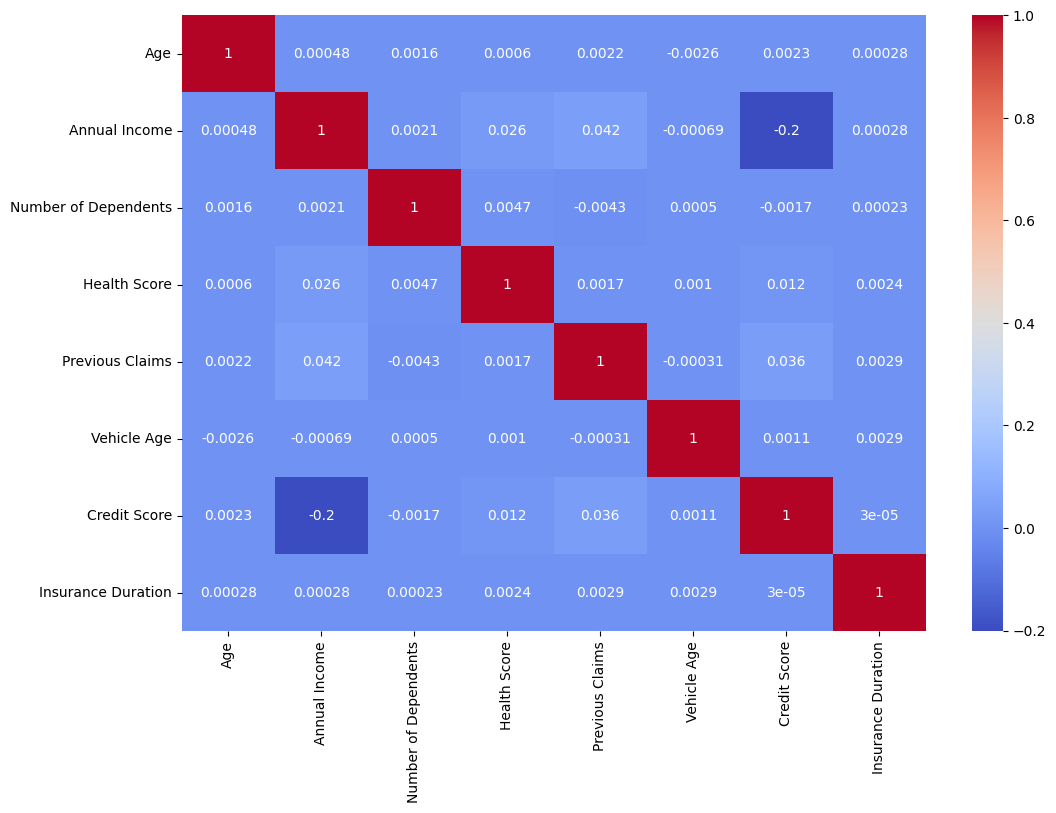

In [61]:
plt.figure(figsize=(12,8))

sns.heatmap(
    X_train[num_cols_train].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [62]:
# 1. No features are highly correlated with each other . 
# 2. Any correlation above 0.7? - NO
# 3. Any multicollinearity? - NO , multicollinearity typically occurs when two or more 
#     independent variables are highly correlated (ex - |r| > 0.7 or 0.8)
# 4. Should any feature be removed? - NO , Features are nearly independent(uncorrelated), 
#      they each likely cotribute unique information to a model . 

In [63]:
train_df = X_train.copy()

train_df['Premium Amount'] = y_train

corr_target = train_df.corr(numeric_only=True)['Premium Amount']

print(corr_target.sort_values(ascending=False))

Premium Amount          1.000000
Previous Claims         0.047092
Health Score            0.016036
Insurance Duration     -0.000358
Vehicle Age            -0.000360
Number of Dependents   -0.000749
Age                    -0.002265
Annual Income          -0.011563
Credit Score           -0.025949
Name: Premium Amount, dtype: float64


In [64]:
# 1. Which features affect Premium Amount most? - Features with highest positive correlation - Previous Claims, Health Score . 
# 2. Which features have weak relationships? - Almost all features show extremely negligible or non-zero correlation.
# 3. Which features may be important? - Premium Amount is the most important relative to others .
#    while Credit Score and Annual Income also show slightly higher movement compared to near zero-features, though they have negative correlations.

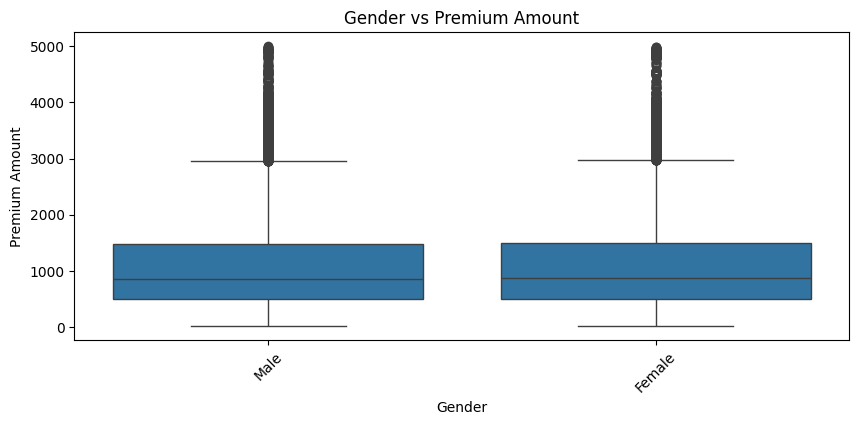

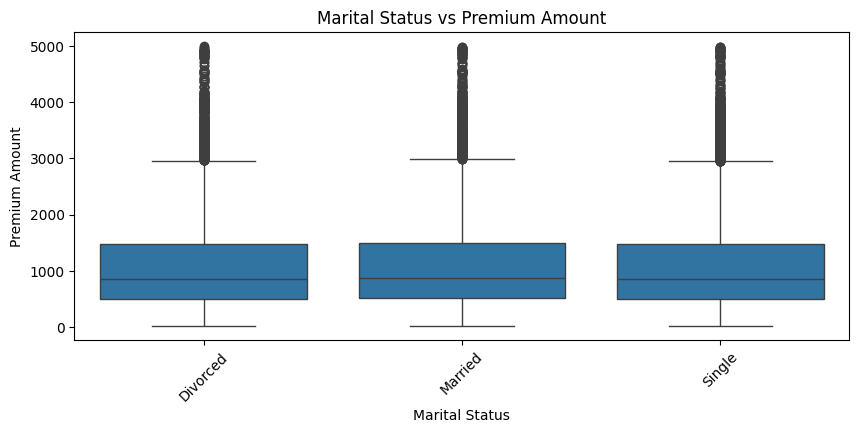

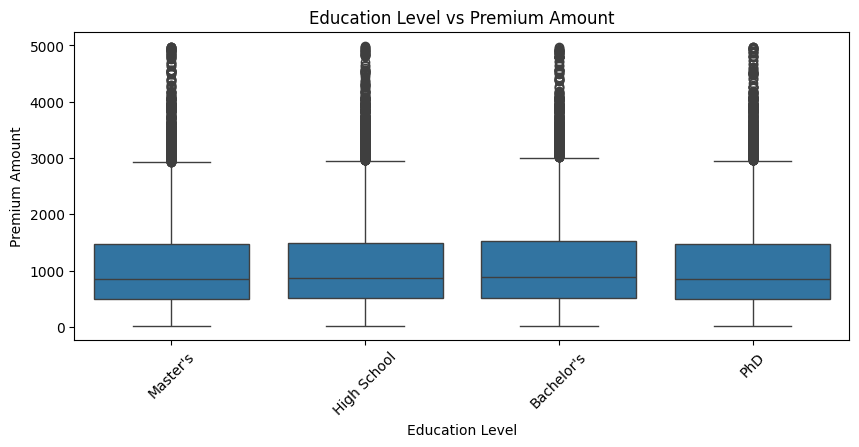

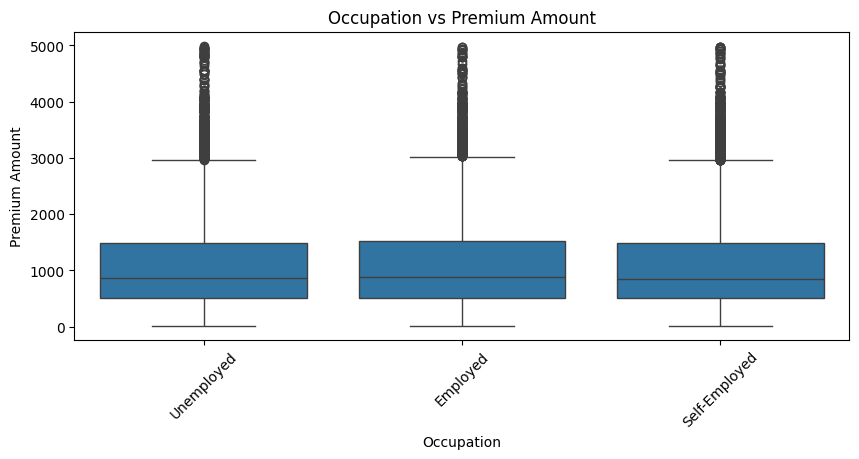

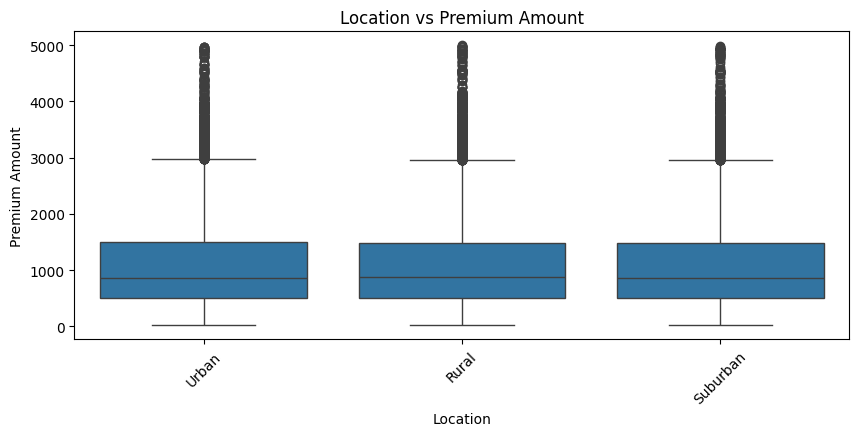

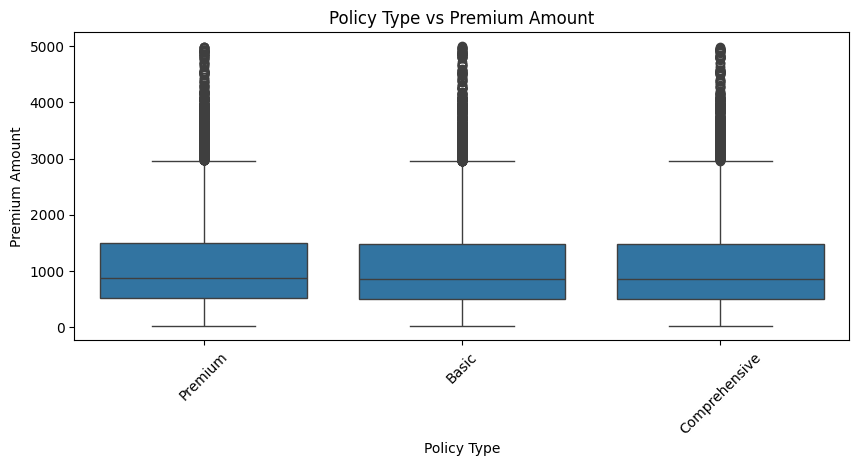

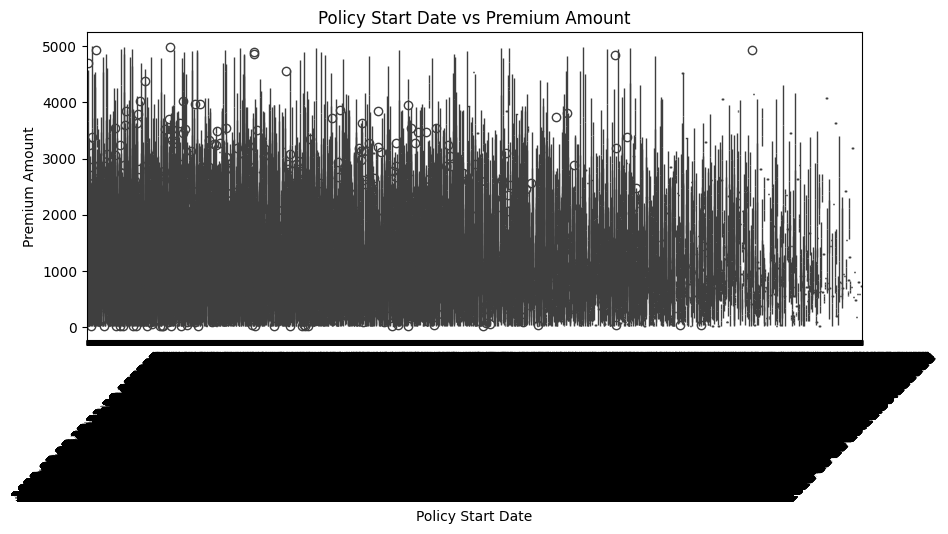

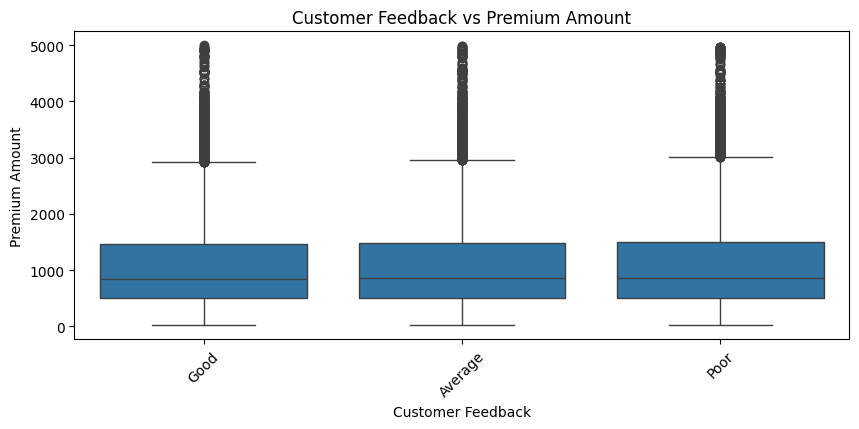

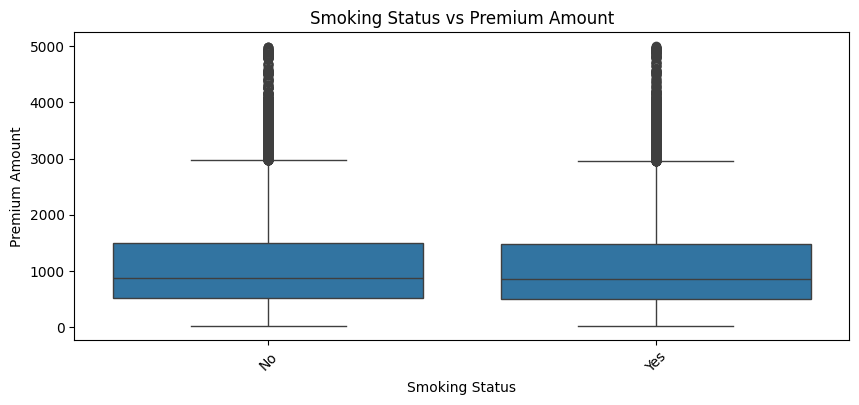

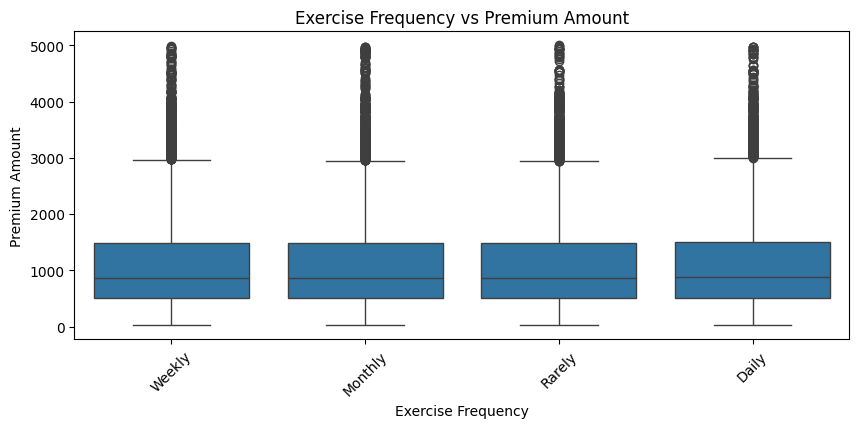

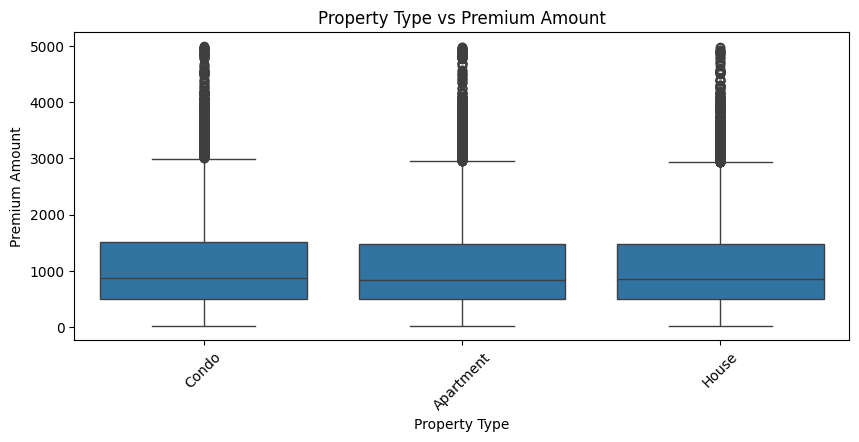

In [65]:
sample_df = train_df.sample(50000, random_state=42)

cat_cols_train = X_train.select_dtypes(include='object').columns

for col in cat_cols_train:

    plt.figure(figsize=(10,4))

    sns.boxplot(
        data=sample_df,
        x=col,
        y='Premium Amount'
    )

    plt.xticks(rotation=45)
    plt.title(f'{col} vs Premium Amount')

    plt.show()

In [66]:
# 1. Do categories have different premium amounts? - NO 
# 2. Does the feature appear useful? - NO
# 3. Is there a meaningful ordering? - NO meaningful natural odering.

# DETAILED EDA ON TRAIN DATA (X_train)

1. Missing Value Analysis

Columns requiring imputation:

* Age
* Annual Income
* Marital Status
* Number of Dependents
* Occupation
* Health Score
* Previous Claims
* Credit Score
* Vehicle Age
* Insurance Duration
* Customer Feedback

Observations:

* Occupation and Previous Claims have the highest missing percentages.
* No column is missing enough data to be dropped immediately.
* Imputation will be required during preprocessing.

---

2. Numerical Feature Distribution Analysis

Age

* Approximately symmetric.
* No major issues.

Annual Income

* Wide range.
* Likely right-skewed.

Number of Dependents

* Discrete feature.
* Small range (0-4).

Health Score

* Fairly spread.
* No obvious abnormalities.

Previous Claims

* Strongly right-skewed.
* Most customers have 0-2 claims.

Vehicle Age

* Nearly uniform distribution.
* Even spread across values.

Credit Score

* Well distributed.
* Closest to normal among numerical features.

Insurance Duration

* Discrete feature (1-9 years).
* Nearly uniform distribution.

---

3. Outlier Analysis

Previous Claims

* Outliers present at higher claim counts (6-8).
* Not removed during EDA.

Vehicle Age

* No significant outliers.

Credit Score

* No significant outliers.

Insurance Duration

* No significant outliers.

Target (Premium Amount)

* Outliers detected.
* Keep for now.
* Revisit after baseline model.

General Rule:

* Detect outliers now.
* Do not remove during EDA.

---

4. Normality Analysis (QQ Plots)

Previous Claims

* Not normally distributed.

Vehicle Age

* Not normally distributed.

Credit Score

* Closest to normal.

Insurance Duration

* Not normally distributed.

Observation:

* Most numerical features are not normally distributed.
* This is acceptable for tree-based models.

---

5. Correlation Analysis

Observations:

* No highly correlated numerical features.
* Highest correlation ≈ -0.20.
* No serious multicollinearity detected.

Decision:

* No feature removal based on correlation.

---

6. Feature vs Target Analysis

Observations:

* Numerical features show weak linear correlations with Premium Amount.
* Relationships may be non-linear.
* Tree-based models may capture these relationships better than Linear Regression.

---

7. Categorical Feature Analysis

Encoding Decisions:

One-Hot Encoding

* Gender
* Marital Status
* Occupation
* Smoking Status
* Location
* Policy Type
* Property Type

Ordinal Encoding

* Education Level
  High School < Bachelor's < Master's < PhD

* Customer Feedback
  Poor < Average < Good

* Exercise Frequency
  Rarely < Monthly < Weekly < Daily

---

8. Date Feature Analysis

Policy Start Date

* High-cardinality feature.
* Convert to datetime.

Planned Features:

* Year
* Month
* Day
* Weekday

Original date column may be dropped after extraction.

---

9. EDA Conclusions

✓ Regression problem

✓ No data leakage so far

✓ Train-test split completed before preprocessing

✓ Missing values identified

✓ Encoding strategy decided

✓ Date feature engineering planned

✓ Outliers identified but not removed

✓ No severe multicollinearity

✓ Numerical features mostly non-normal

✓ Dataset suitable for baseline models

---



# Build preprocessing pipeline:

1. Imputation
2. Encoding
3. Date feature extraction
4. Scaling decision
5. ColumnTransformer
6. Baseline model training

In [67]:
# create the column lists.
onehot_cols = [
    'Gender',
    'Marital Status',
    'Occupation',
    'Smoking Status',
    'Location',
    'Policy Type',
    'Property Type'
]

In [68]:
ordinal_cols = [
    'Education Level',
    'Customer Feedback',
    'Exercise Frequency'
]

In [69]:
date_cols = [
    'Policy Start Date'
]

In [70]:
num_cols = [
    'Age',
    'Annual Income',
    'Number of Dependents',
    'Health Score',
    'Previous Claims',
    'Vehicle Age',
    'Credit Score',
    'Insurance Duration'
]

In [71]:
print(len(onehot_cols))
print(len(ordinal_cols))
print(len(date_cols))
print(len(num_cols))

7
3
1
8


In [72]:
# Column Groups Finalized

# Numerical Features (8)
# - Age
# - Annual Income
# - Number of Dependents
# - Health Score
# - Previous Claims
# - Vehicle Age
# - Credit Score
# - Insurance Duration

# One-Hot Features (7)
# - Gender
# - Marital Status
# - Occupation
# - Smoking Status
# - Location
# - Policy Type
# - Property Type

# Ordinal Features (3)
# - Education Level
# - Customer Feedback
# - Exercise Frequency

# Date Features (1)
# - Policy Start Date

In [73]:
# Imputation Strategy

# Numerical Features
# - Median Imputation

# One-Hot Features
# - Most Frequent Imputation

# Ordinal Features
# - Most Frequent Imputation

# Date Features
# - No missing values
# - No imputation needed

In [74]:
X_train["Policy Start Date"] = pd.to_datetime(
    X_train["Policy Start Date"]
)

X_test["Policy Start Date"] = pd.to_datetime(
    X_test["Policy Start Date"]
)

In [82]:
for df_ in [X_train, X_test]:

    df_["policy_year"] = df_["Policy Start Date"].dt.year
    df_["policy_month"] = df_["Policy Start Date"].dt.month
    df_["policy_day"] = df_["Policy Start Date"].dt.day
    df_["policy_weekday"] = df_["Policy Start Date"].dt.weekday

In [83]:
for df_ in [X_train, X_test]:

    df_["policy_year"] = df_["Policy Start Date"].dt.year
    df_["policy_month"] = df_["Policy Start Date"].dt.month
    df_["policy_day"] = df_["Policy Start Date"].dt.day
    df_["policy_weekday"] = df_["Policy Start Date"].dt.weekday

In [84]:
num_cols.extend([
    "policy_year",
    "policy_month",
    "policy_day",
    "policy_weekday"
])

In [ ]:
# Date Feature Engineering

# Policy Start Date converted to datetime.

# Extracted:
# - policy_year
# - policy_month
# - policy_day
# - policy_weekday

# Original datetime column dropped.

# Reason:
# Linear Regression cannot directly use datetime objects.

In [85]:
# Check Skewness
X_train[num_cols].skew().sort_values(ascending=False)

Annual Income           1.471732
Previous Claims         0.903723
Health Score            0.281604
policy_day              0.008363
policy_month            0.006962
policy_weekday          0.005900
policy_year            -0.007600
Insurance Duration     -0.007898
Number of Dependents   -0.011463
Age                    -0.013827
Vehicle Age            -0.021158
Credit Score           -0.114053
dtype: float64

In [86]:
y_train.skew()

np.float64(1.2411819858759487)

In [ ]:
# Skewness Analysis

# Highly Skewed:
# - Annual Income (1.47)

# Moderately Skewed:
# - Previous Claims (0.90)

# Target:
# - Premium Amount (1.24)

# Approximately Symmetric:
# - Age
# - Number of Dependents
# - Health Score
# - Vehicle Age
# - Credit Score
# - Insurance Duration
# - policy_year
# - policy_month
# - policy_day
# - policy_weekday

In [ ]:
# I would do:

# Features
# Annual Income      → Yeo-Johnson Transform
# Previous Claims    → Yeo-Johnson Transform

# Why Yeo-Johnson?

# Works with zero values.
# More robust than log transform.

In [87]:
y_train_log = np.log1p(y_train)

In [89]:
# pred = np.expm1(pred)

In [90]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('power', PowerTransformer(method='yeo-johnson')),
    ('scaler', StandardScaler())
])

In [91]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_order = [
    ['High School', "Bachelor's", "Master's", 'PhD'],
    ['Poor', 'Average', 'Good'],
    ['Rarely', 'Monthly', 'Weekly', 'Daily']
]

ord_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=ordinal_order))
])

In [92]:
from sklearn.preprocessing import OneHotEncoder

ohe_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
Numerical Pipeline
- Median Imputation
- Yeo-Johnson Transformation
- Standard Scaling

Ordinal Pipeline
- Most Frequent Imputation
- Ordinal Encoding

One-Hot Pipeline
- Most Frequent Imputation
- One-Hot Encoding

In [93]:
# ColumnTransformer 

In [94]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('ord', ord_pipeline, ordinal_cols),
        ('ohe', ohe_pipeline, onehot_cols)
    ]
)

In [95]:
print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('power', PowerTransformer()),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Annual Income',
                                  'Number of Dependents', 'Health Score',
                                  'Previous Claims', 'Vehicle Age',
                                  'Credit Score', 'Insurance Duration',
                                  'policy_year', 'policy_month', 'policy_day',
                                  'policy_weekday']),
                                ('ord',
                                 Pi...
                                                                             ['Poor',
                                                                              'Aver

In [106]:
df.head()

,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount
0,19.0,Female,10049.0,Married,1.0,Bachelor's,Self-Employed,22.598761,Urban,Premium,2.0,17.0,372.0,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0
1,39.0,Female,31678.0,Divorced,3.0,Master's,NaN,15.569731,Rural,Comprehensive,1.0,12.0,694.0,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0
2,23.0,Male,25602.0,Divorced,3.0,High School,Self-Employed,47.177549,Suburban,Premium,1.0,14.0,NaN,3.0,2023-09-30 15:21:39.221386,Good,Yes,Weekly,House,567.0
3,21.0,Male,141855.0,Married,2.0,Bachelor's,NaN,10.938144,Rural,Basic,1.0,0.0,367.0,1.0,2024-06-12 15:21:39.226954,Poor,Yes,Daily,Apartment,765.0
4,21.0,Male,39651.0,Single,1.0,Bachelor's,Self-Employed,20.376094,Rural,Premium,0.0,8.0,598.0,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0


In [ ]:
ColumnTransformer Created

Numerical Features:
- Median Imputation
- Yeo-Johnson Transform
- Standard Scaling

Ordinal Features:
- Most Frequent Imputation
- Ordinal Encoding

One-Hot Features:
- Most Frequent Imputation
- One-Hot Encoding

All preprocessing steps combined into a single object.

In [96]:
X_train_processed = preprocessor.fit_transform(X_train)

In [ ]:
What happens internally?

Numerical:
- Median values learned
- Yeo-Johnson parameters learned
- Mean and Std for scaling learned

Categorical:
- Most frequent values learned
- Categories learned for encoding

In [ ]:
Preprocessor fitted on training data only.
All preprocessing statistics learned from X_train.

In [97]:
X_test_processed = preprocessor.transform(X_test)

In [98]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(960000, 34)
(240000, 34)


In [99]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_processed, y_train_log)

LinearRegression()

In [ ]:
Baseline Linear Regression trained on preprocessed training data.
Target variable used: y_train_log.

In [100]:
pred_log = lr.predict(X_test_processed)

In [101]:
pred = np.expm1(pred_log)

In [103]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, pred)

rmse = np.sqrt(mean_squared_error(y_test, pred))

r2 = r2_score(y_test, pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 650.0788110276001
RMSE: 939.7540019924147
R2  : -0.18179394954070993


In [104]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(960000, 34)
(240000, 34)


In [105]:
from sklearn.metrics import r2_score

train_pred = np.expm1(lr.predict(X_train_processed))

print(
    r2_score(y_train, train_pred)
)

-0.18152600473265013


In [107]:
# Model 2: Ridge Regression 
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_processed, y_train_log)

Ridge()

In [108]:
pred_log = ridge.predict(X_test_processed)

pred = np.expm1(pred_log)

In [110]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, pred)

rmse = np.sqrt(mean_squared_error(y_test, pred))

r2 = r2_score(y_test, pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 650.078811348625
RMSE: 939.7540019881357
R2  : -0.18179394952994765


In [111]:
# Lasso Regression 
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.001)

lasso.fit(X_train_processed, y_train_log)

pred_log = lasso.predict(X_test_processed)

pred = np.expm1(pred_log)

print("R2:", r2_score(y_test, pred))

R2: -0.18184905071754542


In [112]:
# ElasticNet
from sklearn.linear_model import ElasticNet

elastic = ElasticNet(
    alpha=0.001,
    l1_ratio=0.5
)

elastic.fit(X_train_processed, y_train_log)

pred_log = elastic.predict(X_test_processed)

pred = np.expm1(pred_log)

print("R2:", r2_score(y_test, pred))

R2: -0.18182079078562374


In [113]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_processed, y_train)

pred = rf.predict(X_test_processed)

print("R2:", r2_score(y_test, pred))

R2: 0.027424787402832496


In [114]:
# XGBoost 
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train_processed, y_train)

pred = xgb.predict(X_test_processed)

print("R2:", r2_score(y_test, pred))

R2: 0.046193149188458404


In [115]:
# LightGBM 
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42
)

lgbm.fit(X_train_processed, y_train)

pred = lgbm.predict(X_test_processed)

print("R2:", r2_score(y_test, pred))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.037753 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 966
[LightGBM] [Info] Number of data points in the train set: 960000, number of used features: 34
[LightGBM] [Info] Start training from score 1102.505529
R2: 0.04928550875372639


In [116]:
# CatBoost 
from catboost import CatBoostRegressor

cat = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    verbose=0,
    random_state=42
)

cat.fit(X_train_processed, y_train)

pred = cat.predict(X_test_processed)

print("R2:", r2_score(y_test, pred))

R2: 0.04509799604615017
